### Name: Abdul Hadi Saqib
### CMS: 467626

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import fetch_california_housing
import os

## Task 1 - Dataset Preparation, Feature Scaling

In [3]:
californiaHousing = fetch_california_housing(as_frame=True)
df = californiaHousing.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
featureColumns = ['MedInc', 'AveRooms', 'Latitude']
X = df[featureColumns]
y = df['MedHouseVal']

data = pd.concat([X, y], axis=1)

trainDf, valDf = train_test_split(data, test_size=0.2, random_state=42)
print(f"Training set: {trainDf.shape}")
print(f"Validation set: {valDf.shape}")

Training set: (16512, 4)
Validation set: (4128, 4)


In [5]:
os.makedirs('data/lab3', exist_ok=True)
trainDf.to_csv('data/lab3/train_data.csv', index=False)
valDf.to_csv('data/lab3/test_data.csv', index=False)

In [6]:
trainData = pd.read_csv('data/lab3/train_data.csv').values
valData = pd.read_csv('data/lab3/test_data.csv').values

xTrain = trainData[:, :-1]
yTrain = trainData[:, -1]
xVal = valData[:, :-1]
yVal = valData[:, -1]

In [7]:
scaler = MinMaxScaler()
xTrain = scaler.fit_transform(xTrain)
xVal = scaler.transform(xVal)

In [8]:
print("xTrain (scaled):")
print(xTrain[:5])
print("\nyTrain:")
print(yTrain[:5])
print("\nxVal (scaled):")
print(xVal[:5])
print("\nyVal:")
print(yVal[:5])

xTrain (scaled):
[[0.19032151 0.02927784 0.01702128]
 [0.22845202 0.02541945 0.12978723]
 [0.25216204 0.03373236 0.22446809]
 [0.09948828 0.02208143 0.01489362]
 [0.21063847 0.03814724 0.45      ]]

yTrain:
[1.03  3.821 1.726 0.934 0.965]

xVal (scaled):
[[0.08146784 0.02342439 0.37340426]
 [0.14009462 0.02943192 0.27553191]
 [0.2055282  0.02189946 0.55851064]
 [0.36121571 0.0374042  0.18404255]
 [0.22241762 0.03264853 0.43297872]]

yVal:
[0.477   0.458   5.00001 2.186   2.78   ]


## Task 2 - Cost Function without and with Regularization

In [9]:
def addBias(X):
    m = X.shape[0]
    return np.hstack((np.ones((m, 1)), X))

In [10]:
def costFunction(X, y, w, lambd):
    m = X.shape[0]
    h = X @ w
    error = h - y
    cost = (1 / (2 * m)) * np.sum(error ** 2)
    reg = (lambd / (2 * m)) * np.sum(w[1:] ** 2)
    return cost + reg

In [11]:
xTrainB = addBias(xTrain)
xValB = addBias(xVal)

w = np.zeros(xTrainB.shape[1])

print("Without Regularization (lambda=0):")
print(f"Training Cost: {costFunction(xTrainB, yTrain, w, 0):.6f}")
print(f"Validation Cost: {costFunction(xValB, yVal, w, 0):.6f}")

print("\nWith Regularization (lambda=0.1):")
print(f"Training Cost: {costFunction(xTrainB, yTrain, w, 0.1):.6f}")
print(f"Validation Cost: {costFunction(xValB, yVal, w, 0.1):.6f}")

Without Regularization (lambda=0):
Training Cost: 2.814871
Validation Cost: 2.766723

With Regularization (lambda=0.1):
Training Cost: 2.814871
Validation Cost: 2.766723


## Task 3 - Gradient Descent without and with Regularization

In [12]:
def gradientDescent(X, y, w, alpha, lambd):
    m = X.shape[0]
    h = X @ w
    error = h - y
    dw = (1 / m) * (X.T @ error)
    dw[1:] += (lambd / m) * w[1:]
    return w - alpha * dw

In [13]:
w = np.zeros(xTrainB.shape[1])
alpha = 0.1
lambd = 0.1

print("Before Gradient Descent:")
print(f"Weights: {w}")
print(f"Training Cost: {costFunction(xTrainB, yTrain, w, lambd):.6f}")
print(f"Validation Cost: {costFunction(xValB, yVal, w, lambd):.6f}")

wUpdated = gradientDescent(xTrainB, yTrain, w, alpha, lambd)

print("\nAfter One Gradient Descent Step:")
print(f"Weights: {wUpdated}")
print(f"Training Cost: {costFunction(xTrainB, yTrain, wUpdated, lambd):.6f}")
print(f"Validation Cost: {costFunction(xValB, yVal, wUpdated, lambd):.6f}")

Before Gradient Descent:
Weights: [0. 0. 0. 0.]
Training Cost: 2.814871
Validation Cost: 2.766723

After One Gradient Descent Step:
Weights: [0.20719469 0.05879588 0.00698994 0.06442156]
Training Cost: 2.338505
Validation Cost: 2.295863


## Task 4 - Training and Validation Program

Final Weights: [ 1.41912144  3.60763722  0.12051781 -0.55920894]
Bias (w0): 1.419121
Feature Weights: [ 3.60763722  0.12051781 -0.55920894]
Final Training Cost: 0.394140
Final Validation Cost: 0.394048


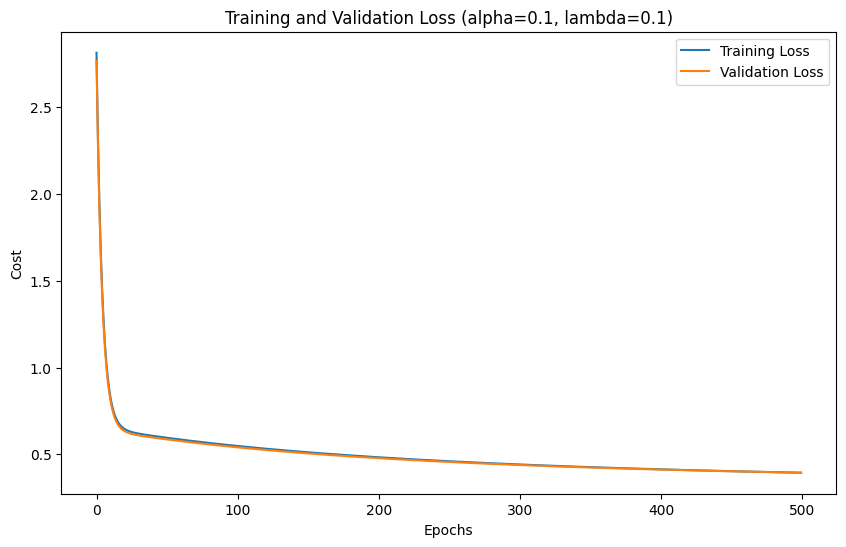

In [14]:
alpha = 0.1
lambd = 0.1
epochs = 500

w = np.zeros(xTrainB.shape[1])
trainLosses = []
valLosses = []

for epoch in range(epochs):
    trainCost = costFunction(xTrainB, yTrain, w, lambd)
    valCost = costFunction(xValB, yVal, w, lambd)
    trainLosses.append(trainCost)
    valLosses.append(valCost)
    w = gradientDescent(xTrainB, yTrain, w, alpha, lambd)

print(f"Final Weights: {w}")
print(f"Bias (w0): {w[0]:.6f}")
print(f"Feature Weights: {w[1:]}")
print(f"Final Training Cost: {trainLosses[-1]:.6f}")
print(f"Final Validation Cost: {valLosses[-1]:.6f}")

plt.figure(figsize=(10, 6))
plt.plot(trainLosses, label='Training Loss')
plt.plot(valLosses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.title(f'Training and Validation Loss (alpha={alpha}, lambda={lambd})')
plt.legend()
plt.show()

## Task 5 - Tuning Alpha and Lambda

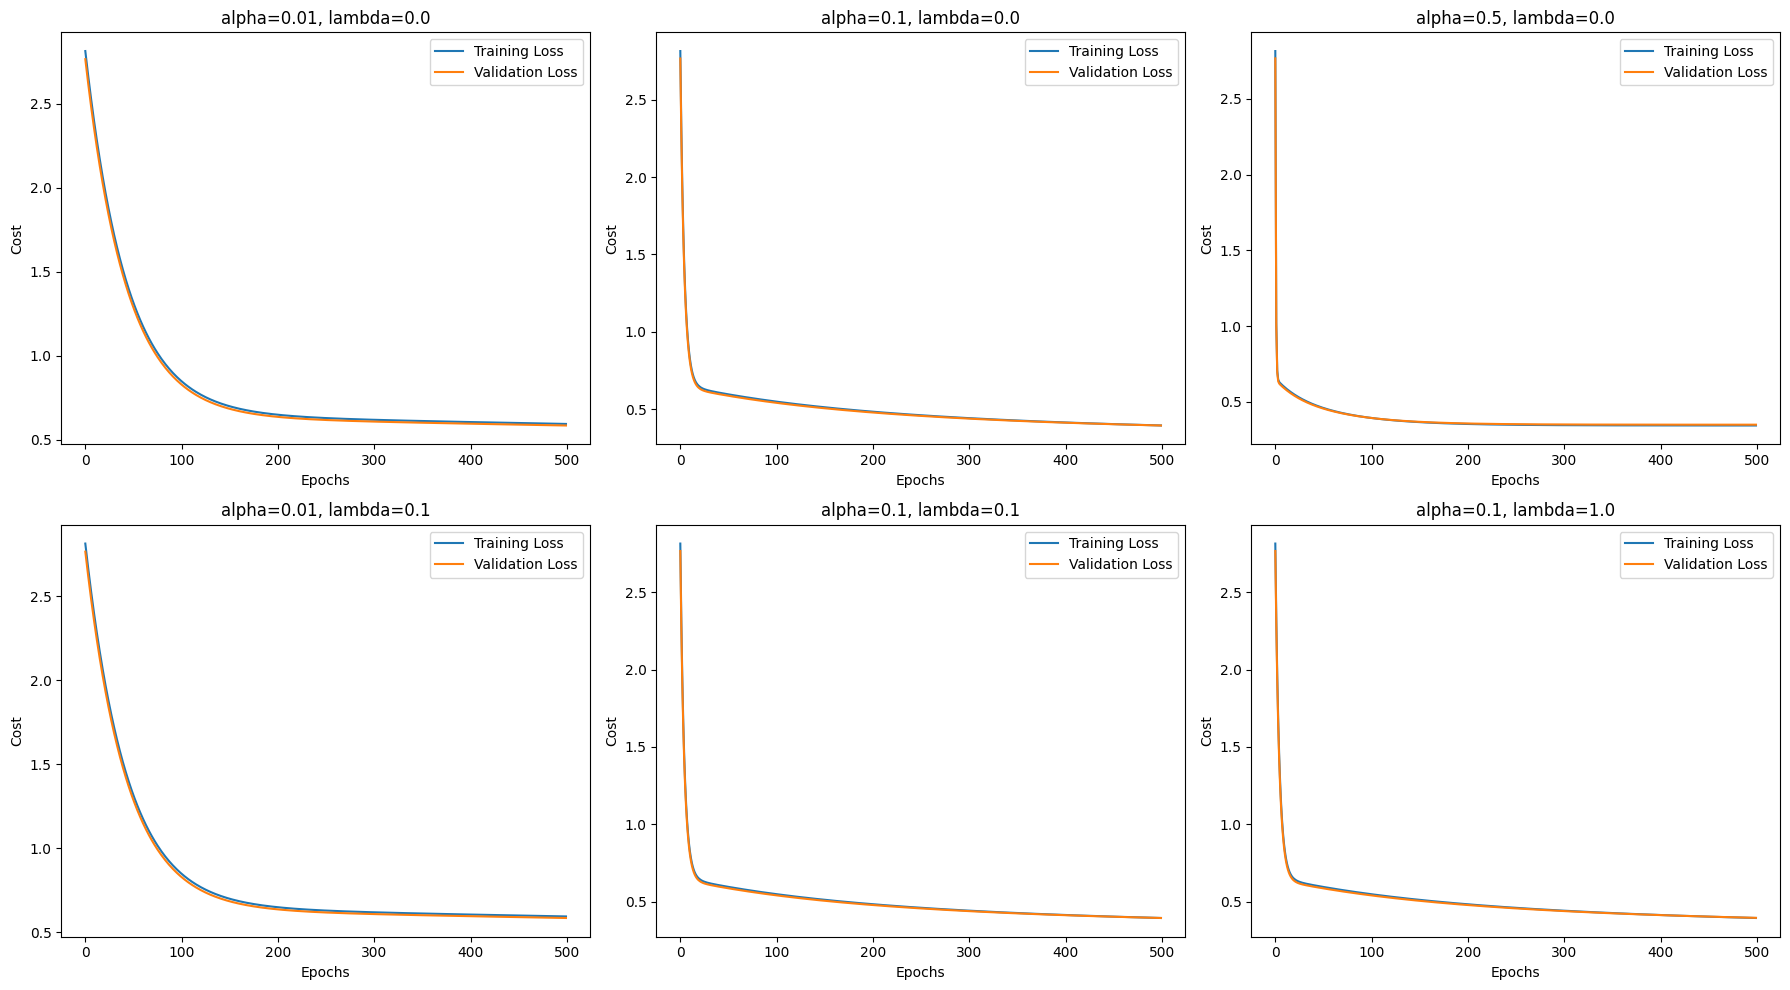

In [15]:
hyperparams = [
    (0.01, 0.0),
    (0.1, 0.0),
    (0.5, 0.0),
    (0.01, 0.1),
    (0.1, 0.1),
    (0.1, 1.0),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (a, l) in enumerate(hyperparams):
    w = np.zeros(xTrainB.shape[1])
    tLosses = []
    vLosses = []

    for epoch in range(500):
        tLosses.append(costFunction(xTrainB, yTrain, w, l))
        vLosses.append(costFunction(xValB, yVal, w, l))
        w = gradientDescent(xTrainB, yTrain, w, a, l)

    axes[i].plot(tLosses, label='Training Loss')
    axes[i].plot(vLosses, label='Validation Loss')
    axes[i].set_xlabel('Epochs')
    axes[i].set_ylabel('Cost')
    axes[i].set_title(f'alpha={a}, lambda={l}')
    axes[i].legend()

plt.tight_layout()
plt.show()